# Explored

- Dataload/Transform

- Split/bootstrap data

- principle component analysis

- clustering as prediction

# Not done yet....

Train resnet?

more models?

In [47]:

import torch


torch.cuda.is_available()

True

Obligitory dataloaders.  see other notebook for working out for these, but load data/transform normalize spectograms

Dataset is a number of different drone signals

- https://www.kaggle.com/datasets/sgluege/noisy-drone-rf-signal-classification-v2/data


In [48]:
from torchaudio.transforms import Spectrogram
from torch.utils.data import Dataset
import os
import matplotlib.pyplot as plt

device = torch.device("cuda")

class SpectrogramTransform:
    def __init__(self):
        self.spectrogram_transform = Spectrogram()

    def __call__(self, iq_data):
        spectrogram = self.spectrogram_transform(iq_data['x_iq'])

        # normalize the spectrogram
        spectrogram = (spectrogram - spectrogram.mean()) / spectrogram.std()
        
        return spectrogram



class DroneRFDataSet(Dataset):
    def __init__(self, data_path, Transform, samplesize=None, device=None):
        self.samplesize = samplesize
        self.data_path = data_path
        self.device = device if device is not None else torch.device("cuda")
        self.files = [f for f in os.listdir(data_path) if f.endswith(".pt") and f.startswith("IQdata")]
        self.transform = Transform

        self.samples = []
        self.targets = []
        self.snrs = []

        # eg IQdata_sample1_target0_snr-16.pt
        for file in self.files:
            sample_id = file.split('_')[1][6:]
            target = file.split('_')[2][6:]
            # snr = file.split('.')[0].split('-')[-1]

            self.samples.append(sample_id)
            self.targets.append(target)
            # self.snrs.append(snr)
        
        if self.samplesize is not None:
            self.files = self.files[:self.samplesize]
            self.samples = self.samples[:self.samplesize]
            self.targets = self.targets[:self.samplesize]
            self.snrs = self.snrs[:self.samplesize]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        file = self.files[index]

        # get the sample id, target, and snr for the given index
        sample_id = self.samples[index]
        target = self.targets[index]
        # snr = self.snrs[index]

        # load data
        data = torch.load(os.path.join(self.data_path, file))

        data = self.transform(data)



        return sample_id, target, data

def showspectrogram(data):
    plt.figure(figsize=(10, 4))
    plt.imshow(data.log2()[0,:,:].detach().cpu(), aspect='auto', origin='lower')
    plt.title("Spectrogram")
    plt.xlabel("Time")
    plt.show()


visualise spectograms

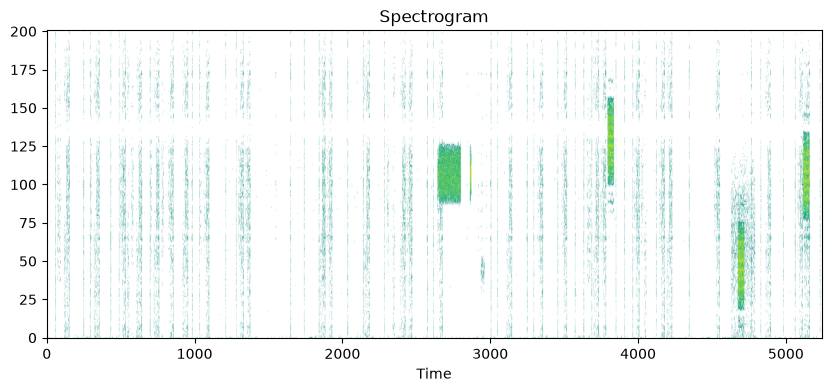

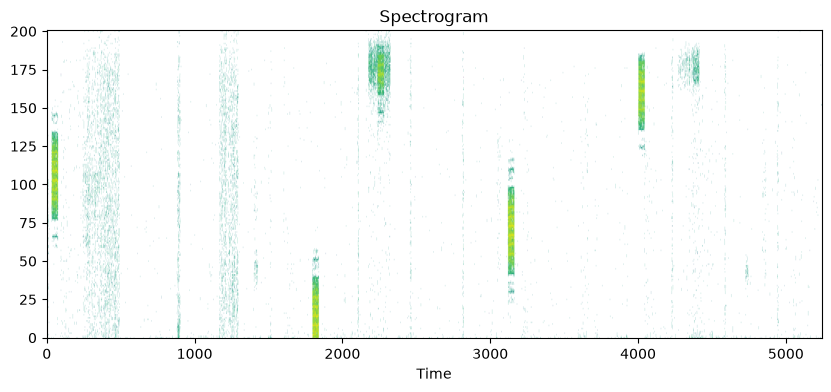

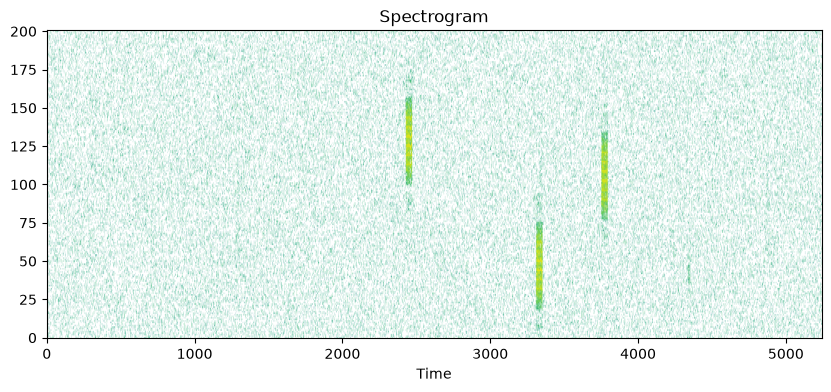

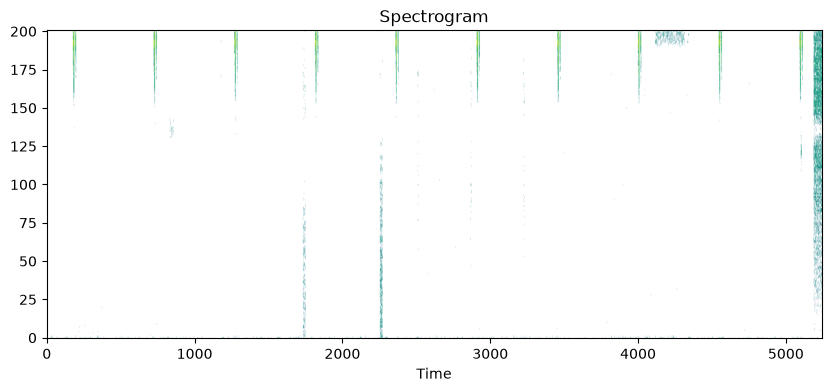

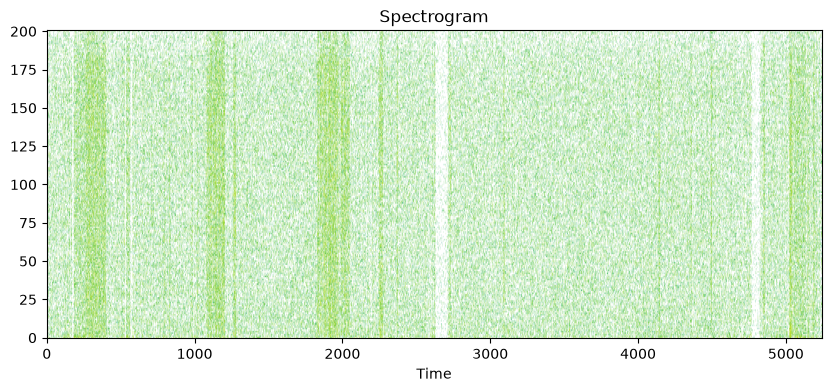

In [49]:
import random

data_path = "../data"

for i in range(5):

    randidx = random.randint(0, len(os.listdir(data_path)) - 1)

    dataset = DroneRFDataSet(data_path, SpectrogramTransform())
    sample_id, target, data = dataset[randidx]

    showspectrogram(data)

make some basic embeddings

In [ ]:


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np

class HeadlessSimpleCNN(nn.Module):
    """Simple small headless CNN."""

    def __init__(self, in_channels: int = 1, channels=(32, 64, 128)):
        super().__init__()
        layers = []
        c_in = in_channels
        for c_out in channels:
            layers.extend(
                [
                    nn.Conv2d(c_in, c_out, kernel_size=3, stride=1, padding=1),
                    nn.BatchNorm2d(c_out),
                    nn.ReLU(inplace=True),
                    nn.MaxPool2d(kernel_size=2),
                ]
            )
            c_in = c_out

        self.backbone = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat_map = self.backbone(x)
        emb = F.adaptive_avg_pool2d(feat_map, output_size=1).flatten(1)
        return emb
    
model = HeadlessSimpleCNN(in_channels=2)  

#sample dataset
sampledataset = DroneRFDataSet(data_path, SpectrogramTransform(), samplesize=1000)

loader = DataLoader(sampledataset, batch_size=64, shuffle=False)
model = model.to(device).eval()

# embeddings = []
# targets, sample_ids = [], []

# for sample_id, target, x in loader:
#     x = x.to(device)

#     # print(x.shape)

#     emb = model(x).detach().cpu().numpy()
#     embeddings.append(emb)

#     sample_ids.extend(sample_id)
#     targets.extend([int(t) for t in target])
#     # snrs.extend([int(s) for s in snr])

# embeddings = np.concatenate(embeddings, axis=0)

# embeddings

array([[9.2964787e-03, 2.3714723e-02, 1.4178474e-01, ..., 4.2129620e-03,
        9.7187627e-03, 1.5580968e-04],
       [3.3369202e-02, 4.2183001e-02, 1.5525666e-01, ..., 4.1980971e-02,
        4.9605954e-02, 5.1509370e-03],
       [2.5993621e-02, 2.4872816e-03, 1.6370140e-02, ..., 6.8709115e-03,
        2.7742662e-02, 5.2109017e-04],
       ...,
       [1.8625168e-02, 2.4890446e-03, 9.1582183e-03, ..., 4.0414566e-03,
        2.2399863e-02, 5.0933199e-04],
       [2.6376870e-02, 8.9561002e-04, 2.0109897e-02, ..., 8.3670001e-03,
        2.5079895e-02, 1.9470559e-04],
       [4.1396911e-03, 3.7127431e-02, 2.7191383e-01, ..., 7.1914174e-04,
        3.4659952e-03, 6.8972855e-05]], shape=(1000, 128), dtype=float32)

In [ ]:
# pickle them because it took forefer

# import pickle

# with open("embeddings.pkl", "wb") as f:
#     pickle.dump(embeddings, f)

In [54]:
import pickle

with open("embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

In [55]:
embeddings

array([[9.2964787e-03, 2.3714723e-02, 1.4178474e-01, ..., 4.2129620e-03,
        9.7187627e-03, 1.5580968e-04],
       [3.3369202e-02, 4.2183001e-02, 1.5525666e-01, ..., 4.1980971e-02,
        4.9605954e-02, 5.1509370e-03],
       [2.5993621e-02, 2.4872816e-03, 1.6370140e-02, ..., 6.8709115e-03,
        2.7742662e-02, 5.2109017e-04],
       ...,
       [1.8625168e-02, 2.4890446e-03, 9.1582183e-03, ..., 4.0414566e-03,
        2.2399863e-02, 5.0933199e-04],
       [2.6376870e-02, 8.9561002e-04, 2.0109897e-02, ..., 8.3670001e-03,
        2.5079895e-02, 1.9470559e-04],
       [4.1396911e-03, 3.7127431e-02, 2.7191383e-01, ..., 7.1914174e-04,
        3.4659952e-03, 6.8972855e-05]], shape=(1000, 128), dtype=float32)

cluster the embeddings

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def run_kmeans(embeddings: np.ndarray, n_clusters: int, normalize: bool = True, random_state: int = 42):
    x = StandardScaler().fit_transform(embeddings) if normalize else embeddings
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = km.fit_predict(x)
    sil = silhouette_score(x, labels) if n_clusters > 1 else float("nan")
    return labels, sil

labels, sil = run_kmeans(embeddings, n_clusters=len(np.unique(targets)))

print(f"Silhouette score: {sil:.4f}")


Silhouette score: 0.6378


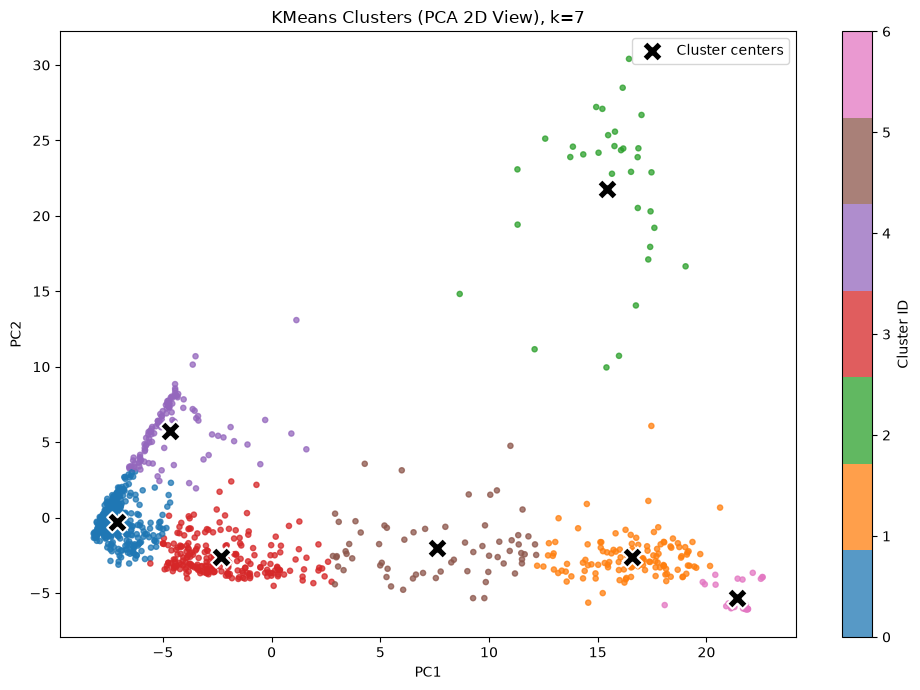

In [57]:
# snagged some code online for plotting KMeans clusters with PCA projection

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# Use one consistent feature space for both KMeans and PCA projection
n_clusters = 7
X = StandardScaler().fit_transform(embeddings)

km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
labels = km.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(X)
centers_2d = pca.transform(km.cluster_centers_)

# Discrete colormap for cluster ids
base_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
cmap = ListedColormap(base_colors[:n_clusters])

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    cmap=cmap,
    s=14,
    alpha=0.75,
)

plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    c="black",
    s=220,
    marker="X",
    linewidths=1.5,
    edgecolors="white",
    label="Cluster centers",
)

plt.title(f"KMeans Clusters (PCA 2D View), k={n_clusters}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="best")

cbar = plt.colorbar(scatter, ticks=range(n_clusters))
cbar.set_label("Cluster ID")

plt.tight_layout()
plt.show()

Could look for significant features here (but i dont think i know enough about bluetooth to know whats a feature here....) so lets build a predictor

In [81]:
from collections import Counter

X_train = embeddings

# Use true class labels (targets), not cluster labels
Y_train = np.array([int(t) for t in targets], dtype=int)

scaler = StandardScaler()
Xs = scaler.fit_transform(X_train)

# Fit a fresh KMeans model used for prediction
n_clusters = len(np.unique(Y_train))
km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
cluster_ids = km.fit_predict(Xs)

# Map each cluster to the most common true class within that cluster
cluster_to_class = {}
for c in range(n_clusters):
    cls_in_cluster = Y_train[cluster_ids == c]
    cluster_to_class[c] = Counter(cls_in_cluster).most_common(1)[0][0]

def predict_class(new_embedding_1d):
    x = np.asarray(new_embedding_1d).reshape(1, -1)
    x = scaler.transform(x)
    c = int(km.predict(x)[0])
    return int(cluster_to_class[c]), c

In [84]:
Y_train

array([0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4,

try it once

In [75]:
randidx = random.randint(0, len(embeddings) - 1)

filenames = sorted([f for f in os.listdir(data_path) if f.endswith(".pt") and f.startswith("IQdata")])
filename = filenames[randidx]

target = int(filename.split('_')[2][6:])

new_embedding = embeddings[randidx]

pred_class, pred_cluster = predict_class(new_embedding)
print(f"Predicted class: {pred_class}, Predicted cluster: {pred_cluster}", f"Target: {target}")

filename = filenames[randidx]

Predicted class: 4, Predicted cluster: 0 Target: 4


In [80]:
def scoreall(embeddings, data_path):
    filenames = sorted([f for f in os.listdir(data_path) if f.endswith(".pt") and f.startswith("IQdata")])

    # Guard against mismatch between files and embedding count
    n = min(len(embeddings), len(filenames))

    correct = 0
    for randidx in range(n):
        filename = filenames[randidx]
        target = int(filename.split('_')[2][6:])
        new_embedding = embeddings[randidx]
        pred_class, pred_cluster = predict_class(new_embedding)
        if pred_class == target:
            correct += 1

    return correct / n if n > 0 else 0

results = scoreall(embeddings, data_path)
print(f"Accuracy: {results:.4f}")

Accuracy: 0.9000


In [ ]:
# simple resnet training

# model = torchvision.models.resnet18(pretrained=True)

class CNNWithclassifier(nn.Module):
    def __init__(self, base_model, num_classes):
        self.base_model = base_model
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)
    

In [82]:
# simple 3 block cnn

class DirectEmbeddingCNN(nn.Module):
    def __init__(self, in_channels=2, num_classes=7, emb_dim=128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.embedding_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, emb_dim),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        emb = self.embedding_head(x)
        logits = self.classifier(emb)
        return emb, logits


num_classes = len({int(f.split('_')[2][6:]) for f in os.listdir(data_path) if f.endswith('.pt') and f.startswith('IQdata')})
train_dataset = DroneRFDataSet(data_path, SpectrogramTransform(), samplesize=600)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = DirectEmbeddingCNN(in_channels=2, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

for epoch in range(5):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for _, target, x in train_loader:
        x = x.to(device)
        y = torch.tensor([int(t) for t in target], device=device)

        optimizer.zero_grad()
        emb, logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        running_correct += (logits.argmax(1) == y).sum().item()
        running_total += x.size(0)

    print(f"epoch {epoch + 1}: loss={running_loss / running_total:.4f}, acc={running_correct / running_total:.4f}")


epoch 1: loss=1.0226, acc=0.8267
epoch 2: loss=0.3404, acc=0.9000
epoch 3: loss=0.3078, acc=0.9000
epoch 4: loss=0.2840, acc=0.9000
epoch 5: loss=0.2797, acc=0.9000


In [83]:
# on unseen data (maybe, really need to split before i )

test_dataset = DroneRFDataSet(data_path, SpectrogramTransform(), samplesize=600)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
model.eval()

all_preds = []
with torch.no_grad():
    for _, target, x in test_loader:
        x = x.to(device)
        emb, logits = model(x)
        preds = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())

all_preds = np.array(all_preds)
print(all_preds)
print("Number of predictions:", len(all_preds))
print("Unique predictions:", np.unique(all_preds))
print("Prediction counts:", np.bincount(all_preds))


[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 